<a href="https://colab.research.google.com/github/Anushkagupta2/earthquake-prediction/blob/main/Earthquake_model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv('database.csv')

In [ ]:
data.head(5)

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,Earthquake,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,Automatic
1,01/04/1965,11:29:49,1.863,127.352,Earthquake,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,Automatic
2,01/05/1965,18:05:58,-20.579,-173.972,Earthquake,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,Automatic
3,01/08/1965,18:49:43,-59.076,-23.557,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,Automatic
4,01/09/1965,13:32:50,11.938,126.427,Earthquake,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,Automatic


In [ ]:
data.isna().sum()

Date                              0
Time                              0
Latitude                          0
Longitude                         0
Type                              0
Depth                             0
Depth Error                   18951
Depth Seismic Stations        16315
Magnitude                         0
Magnitude Type                    3
Magnitude Error               23085
Magnitude Seismic Stations    20848
Azimuthal Gap                 16113
Horizontal Distance           21808
Horizontal Error              22256
Root Mean Square               6060
ID                                0
Source                            0
Location Source                   0
Magnitude Source                  0
Status                            0
dtype: int64

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data['Type'] = le.fit_transform(data['Type'])
data['Status'] = le.fit_transform(data['Status'])

In [ ]:
data.head(5)

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,0,131.6,NaN,NaN,6.0,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,0
1,01/04/1965,11:29:49,1.863,127.352,0,80.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,0
2,01/05/1965,18:05:58,-20.579,-173.972,0,20.0,NaN,NaN,6.2,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,0
3,01/08/1965,18:49:43,-59.076,-23.557,0,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,0
4,01/09/1965,13:32:50,11.938,126.427,0,15.0,NaN,NaN,5.8,MW,...,NaN,NaN,NaN,NaN,NaN,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,0


In [ ]:
data['Root Mean Square'].mean()

1.022783990318119

In [ ]:
data=data.fillna(1.0227)

In [ ]:
data.head(5)

,Date,Time,Latitude,Longitude,Type,Depth,Depth Error,Depth Seismic Stations,Magnitude,Magnitude Type,...,Magnitude Seismic Stations,Azimuthal Gap,Horizontal Distance,Horizontal Error,Root Mean Square,ID,Source,Location Source,Magnitude Source,Status
0,01/02/1965,13:44:18,19.246,145.616,0,131.6,1.0227,1.0227,6.0,MW,...,1.0227,1.0227,1.0227,1.0227,1.0227,ISCGEM860706,ISCGEM,ISCGEM,ISCGEM,0
1,01/04/1965,11:29:49,1.863,127.352,0,80.0,1.0227,1.0227,5.8,MW,...,1.0227,1.0227,1.0227,1.0227,1.0227,ISCGEM860737,ISCGEM,ISCGEM,ISCGEM,0
2,01/05/1965,18:05:58,-20.579,-173.972,0,20.0,1.0227,1.0227,6.2,MW,...,1.0227,1.0227,1.0227,1.0227,1.0227,ISCGEM860762,ISCGEM,ISCGEM,ISCGEM,0
3,01/08/1965,18:49:43,-59.076,-23.557,0,15.0,1.0227,1.0227,5.8,MW,...,1.0227,1.0227,1.0227,1.0227,1.0227,ISCGEM860856,ISCGEM,ISCGEM,ISCGEM,0
4,01/09/1965,13:32:50,11.938,126.427,0,15.0,1.0227,1.0227,5.8,MW,...,1.0227,1.0227,1.0227,1.0227,1.0227,ISCGEM860890,ISCGEM,ISCGEM,ISCGEM,0


In [ ]:
cleaned_data=data[['Date','Time','Latitude','Longitude','Magnitude','Depth']]

In [ ]:
cleaned_data.head(5)

,Date,Time,Latitude,Longitude,Magnitude,Depth
0,01/02/1965,13:44:18,19.246,145.616,6.0,131.6
1,01/04/1965,11:29:49,1.863,127.352,5.8,80.0
2,01/05/1965,18:05:58,-20.579,-173.972,6.2,20.0
3,01/08/1965,18:49:43,-59.076,-23.557,5.8,15.0
4,01/09/1965,13:32:50,11.938,126.427,5.8,15.0


In [ ]:
cleaned_data.isna().sum()

Date         0
Time         0
Latitude     0
Longitude    0
Magnitude    0
Depth        0
dtype: int64

In [ ]:
cleaned_data[3378:3383]

,Date,Time,Latitude,Longitude,Magnitude,Depth
3378,1975-02-23T02:58:41.000Z,1975-02-23T02:58:41.000Z,8.017,124.075,5.6,623.0
3379,02/23/1975,03:53:36,-21.727,-71.356,5.6,33.0
3380,02/23/1975,07:34:11,-10.879,166.667,5.5,33.0
3381,02/25/1975,05:20:05,-7.388,149.798,5.5,33.0
3382,02/26/1975,04:48:55,85.047,97.969,5.6,33.0


In [ ]:
length=cleaned_data.Date.str.len()
length.value_counts()

10    23409
24        3
Name: Date, dtype: int64

In [ ]:
indices=np.where([length==24])[1]
print(indices)

[ 3378  7512 20650]


In [ ]:
cleaned_data.loc[3378,'Date']='02/23/1975'
cleaned_data.loc[7512,'Date']='04/28/1985'
cleaned_data.loc[20650,'Date']='03/13/2011'
cleaned_data.head(5)

,Date,Time,Latitude,Longitude,Magnitude,Depth
0,01/02/1965,13:44:18,19.246,145.616,6.0,131.6
1,01/04/1965,11:29:49,1.863,127.352,5.8,80.0
2,01/05/1965,18:05:58,-20.579,-173.972,6.2,20.0
3,01/08/1965,18:49:43,-59.076,-23.557,5.8,15.0
4,01/09/1965,13:32:50,11.938,126.427,5.8,15.0


In [ ]:
cleaned_data[20650:20652]

,Date,Time,Latitude,Longitude,Magnitude,Depth
20650,03/13/2011,2011-03-13T02:23:34.520Z,36.344,142.344,5.8,10.1
20651,03/13/2011,07:56:43,39.642,143.181,5.7,13.0


In [ ]:
cleaned_data.loc[3378,'Time']='02:58:41'
cleaned_data.loc[7512,'Time']='02:53:41'
cleaned_data.loc[20650,'Time']='02:23:34'

In [ ]:
cleaned_data.head(5)

,Date,Time,Latitude,Longitude,Magnitude,Depth
0,01/02/1965,13:44:18,19.246,145.616,6.0,131.6
1,01/04/1965,11:29:49,1.863,127.352,5.8,80.0
2,01/05/1965,18:05:58,-20.579,-173.972,6.2,20.0
3,01/08/1965,18:49:43,-59.076,-23.557,5.8,15.0
4,01/09/1965,13:32:50,11.938,126.427,5.8,15.0


In [ ]:
cleaned_data['date_parsed'] = pd.to_datetime(cleaned_data['Date'], format="%m/%d/%Y")
year=cleaned_data['date_parsed'].dt.year
cleaned_data.head(5)

,Date,Time,Latitude,Longitude,Magnitude,Depth,date_parsed
0,01/02/1965,13:44:18,19.246,145.616,6.0,131.6,1965-01-02
1,01/04/1965,11:29:49,1.863,127.352,5.8,80.0,1965-01-04
2,01/05/1965,18:05:58,-20.579,-173.972,6.2,20.0,1965-01-05
3,01/08/1965,18:49:43,-59.076,-23.557,5.8,15.0,1965-01-08
4,01/09/1965,13:32:50,11.938,126.427,5.8,15.0,1965-01-09


In [ ]:
cleaned_data['Year'] = cleaned_data['date_parsed'].dt.year
interval=5
cleaned_data.head(5)

,Date,Time,Latitude,Longitude,Magnitude,Depth,date_parsed,Year
0,01/02/1965,13:44:18,19.246,145.616,6.0,131.6,1965-01-02,1965
1,01/04/1965,11:29:49,1.863,127.352,5.8,80.0,1965-01-04,1965
2,01/05/1965,18:05:58,-20.579,-173.972,6.2,20.0,1965-01-05,1965
3,01/08/1965,18:49:43,-59.076,-23.557,5.8,15.0,1965-01-08,1965
4,01/09/1965,13:32:50,11.938,126.427,5.8,15.0,1965-01-09,1965


In [ ]:
cleaned_data['Year Interval'] = pd.cut(cleaned_data['Year'], bins=range(min(cleaned_data['Year']), max(cleaned_data['Year'])+interval, interval), right=False)

In [ ]:
years_drop=[2015,2016]
cleaned_data = cleaned_data[~cleaned_data['Year'].isin(years_drop)]
cleaned_data.tail(5)

,Date,Time,Latitude,Longitude,Magnitude,Depth,date_parsed,Year,Year Interval
22492,12/29/2014,09:29:37,8.6341,121.5213,6.1,8.00,2014-12-29,2014,"[2010, 2015)"
22493,12/29/2014,17:41:49,-56.6590,-24.8509,5.6,19.03,2014-12-29,2014,"[2010, 2015)"
22494,12/30/2014,21:17:24,-20.3263,-178.5639,6.0,599.28,2014-12-30,2014,"[2010, 2015)"
22495,12/31/2014,01:37:34,-4.4378,144.0020,5.8,123.00,2014-12-31,2014,"[2010, 2015)"
22496,12/31/2014,09:26:22,13.7483,120.6673,5.5,110.00,2014-12-31,2014,"[2010, 2015)"


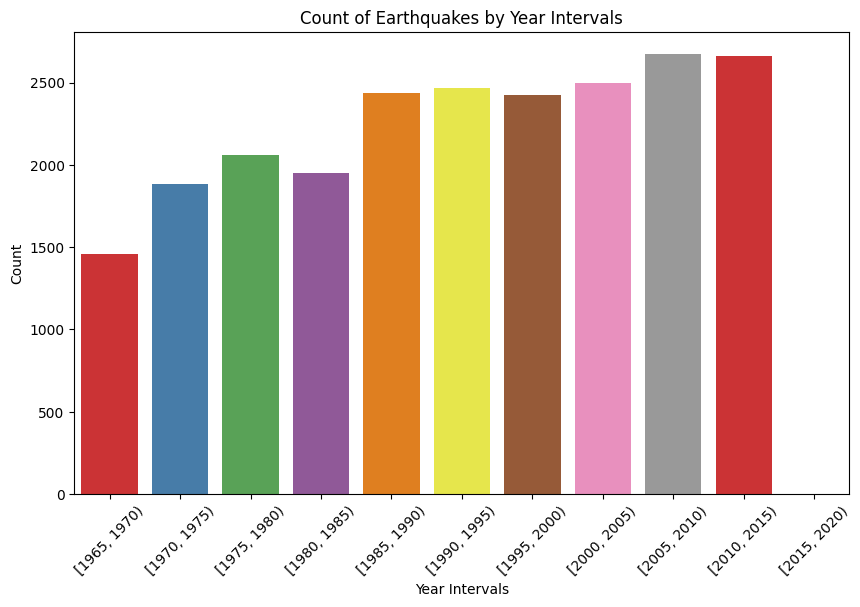

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=cleaned_data, x='Year Interval', palette='Set1')
plt.xlabel('Year Intervals')
plt.ylabel('Count')
plt.title('Count of Earthquakes by Year Intervals')
plt.xticks(rotation=45)
plt.show()


In [ ]:
month=cleaned_data['date_parsed'].dt.month

Text(0.5, 1.0, 'Count of Earthquakes by Months Interval')

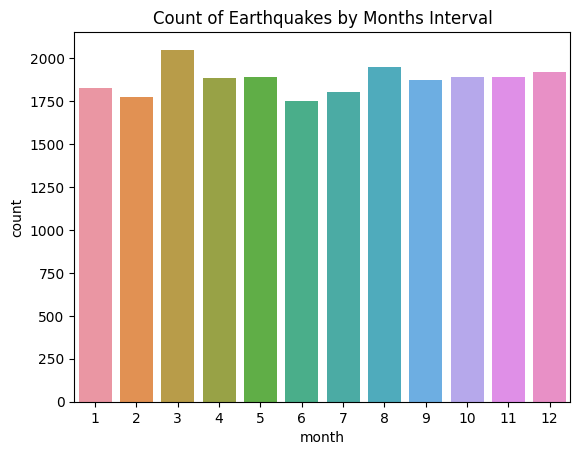

In [ ]:
sns.countplot(x=month,width=0.8)
plt.xlabel('month')
plt.title('Count of Earthquakes by Months Interval')

In [ ]:
cleaned_data.head(5)

,Date,Time,Latitude,Longitude,Magnitude,Depth,date_parsed,Year,Year Interval
0,01/02/1965,13:44:18,19.246,145.616,6.0,131.6,1965-01-02,1965,"[1965, 1970)"
1,01/04/1965,11:29:49,1.863,127.352,5.8,80.0,1965-01-04,1965,"[1965, 1970)"
2,01/05/1965,18:05:58,-20.579,-173.972,6.2,20.0,1965-01-05,1965,"[1965, 1970)"
3,01/08/1965,18:49:43,-59.076,-23.557,5.8,15.0,1965-01-08,1965,"[1965, 1970)"
4,01/09/1965,13:32:50,11.938,126.427,5.8,15.0,1965-01-09,1965,"[1965, 1970)"


In [ ]:
import datetime
import time

timestamp = []
for d, t in zip(cleaned_data['Date'], cleaned_data['Time']):
    try:
        ts = datetime.datetime.strptime(str(d)+' '+str(t), '%m/%d/%Y %H:%M:%S')
        timestamp.append(time.mktime(ts.timetuple()))
    except ValueError:
        # print('ValueError')
        timestamp.append('ValueError')
timeStamp = pd.Series(timestamp)
cleaned_data['Timestamp'] = timeStamp.values
final_data = cleaned_data.drop(['Date', 'Time'], axis=1)
final_data = final_data[final_data.Timestamp != 'ValueError']
final_data.head()

,Latitude,Longitude,Magnitude,Depth,date_parsed,Year,Year Interval,Timestamp
0,19.246,145.616,6.0,131.6,1965-01-02,1965,"[1965, 1970)",-157630542.0
1,1.863,127.352,5.8,80.0,1965-01-04,1965,"[1965, 1970)",-157465811.0
2,-20.579,-173.972,6.2,20.0,1965-01-05,1965,"[1965, 1970)",-157355642.0
3,-59.076,-23.557,5.8,15.0,1965-01-08,1965,"[1965, 1970)",-157093817.0
4,11.938,126.427,5.8,15.0,1965-01-09,1965,"[1965, 1970)",-157026430.0


In [ ]:
timestamp = []
for dt_value in final_data['Timestamp']:
    if isinstance(dt_value, str):  # Process only strings
        try:
            year = int(dt_value[0:4])
            month = int(dt_value[5:7])
            day = int(dt_value[8:10])
            hour = int(dt_value[11:13])
            minute = int(dt_value[14:16])
            second = int(dt_value[17:19])

            dt = datetime(year, month, day, hour, minute, second)
            timestamp.append(int(dt.timestamp()))
        except ValueError:
            # Handle invalid date-time strings if needed
            pass
    else:
        timestamp.append(dt_value)  # Keep floats as they are

final_data['Timestamp'] = pd.Series(timestamp)


In [ ]:
final_data['Timestamp'].dtype

dtype('float64')

In [ ]:
final_data.head(5)

,Latitude,Longitude,Magnitude,Depth,date_parsed,Year,Year Interval,Timestamp
0,19.246,145.616,6.0,131.6,1965-01-02,1965,"[1965, 1970)",-157630542.0
1,1.863,127.352,5.8,80.0,1965-01-04,1965,"[1965, 1970)",-157465811.0
2,-20.579,-173.972,6.2,20.0,1965-01-05,1965,"[1965, 1970)",-157355642.0
3,-59.076,-23.557,5.8,15.0,1965-01-08,1965,"[1965, 1970)",-157093817.0
4,11.938,126.427,5.8,15.0,1965-01-09,1965,"[1965, 1970)",-157026430.0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X=final_data[['Latitude','Longitude']]
Y=final_data[['Magnitude','Depth']]
X_train,X_test,Y_train,Y_test=train_test_split( X,Y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfc=RandomForestRegressor(n_estimators=100,max_depth=15,min_samples_split=5, min_samples_leaf=3)
rfc.fit(X_train,Y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=3, min_samples_split=5)

In [ ]:
rfc.score(X_train,Y_train)

0.5290572122033966

In [ ]:
rfc.score(X_test,Y_test)

0.4349064048348868

In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_estimators':[10, 20, 50, 100, 500]}

grid_obj = GridSearchCV(rfc, parameters)
grid_fit = grid_obj.fit(X_train, Y_train)
best_fit = grid_fit.best_estimator_

In [ ]:
best_fit.score(X_train,Y_train)

0.5304440535059733

In [ ]:
best_fit.score(X_test,Y_test)

0.43389490469604836

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

def create_model(neurons, activation, optimizer, loss):
    model = Sequential()
    model.add(Dense(neurons, activation=activation, input_shape=(2,)))
    model.add(Dense(neurons, activation=activation))
    model.add(Dense(2, activation='softmax'))

    model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

    return model

In [ ]:
from keras.wrappers.scikit_learn import KerasClassifier

model = KerasClassifier(build_fn=create_model, verbose=0)

# neurons = [16, 64, 128, 256]
neurons = [16,64]
# batch_size = [10, 20, 50, 100]
batch_size = [10,20]
epochs = [10,20]
# activation = ['relu', 'tanh', 'sigmoid', 'hard_sigmoid', 'linear', 'exponential']
activation = ['sigmoid', 'relu']
# optimizer = ['SGD', 'RMSprop', 'Adagrad', 'Adadelta', 'Adam', 'Adamax', 'Nadam']
optimizer = ['SGD']
loss = ['squared_hinge']

param_grid = dict(neurons=neurons, batch_size=batch_size, epochs=epochs, activation=activation, optimizer=optimizer, loss=loss)

In [ ]:
from tensorflow.keras import layers
from tensorflow import keras
import tensorflow as tf

#Check the version of TensorFlow you are using
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.12.0
[]


In [ ]:
model = Sequential()
model.add(Dense(16, activation='relu', input_shape=(2,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='SGD', loss='squared_hinge', metrics=['accuracy'])

In [ ]:
model.fit(X_train, Y_train, batch_size=10, epochs=10, verbose=1, validation_data=(X_test, Y_test))

Epoch 1/10
1873/1873 [==============================] - 4s 2ms/step - loss: 0.0158 - accuracy: 0.4608 - val_loss: 0.0040 - val_accuracy: 0.8693
Epoch 2/10
1873/1873 [==============================] - 4s 2ms/step - loss: 0.0043 - accuracy: 0.6746 - val_loss: 0.0040 - val_accuracy: 0.3906
Epoch 3/10
1873/1873 [==============================] - 5s 3ms/step - loss: 0.0042 - accuracy: 0.6349 - val_loss: 0.0040 - val_accuracy: 0.5258
Epoch 4/10
1873/1873 [==============================] - 4s 2ms/step - loss: 0.0039 - accuracy: 0.7640 - val_loss: 0.0040 - val_accuracy: 0.9425
Epoch 5/10
1873/1873 [==============================] - 5s 3ms/step - loss: 0.0040 - accuracy: 0.8538 - val_loss: 0.0039 - val_accuracy: 0.3345
Epoch 6/10
1873/1873 [==============================] - 5s 2ms/step - loss: 0.0046 - accuracy: 0.7547 - val_loss: 0.0040 - val_accuracy: 0.6756
Epoch 7/10
1873/1873 [==============================] - 4s 2ms/step - loss: 0.0039 - accuracy: 0.8764 - val_loss: 0.0039 - val_accuracy:

In [ ]:
[test_loss, test_acc] = model.evaluate(X_test, Y_test)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

147/147 [==============================] - 0s 2ms/step - loss: 0.0039 - accuracy: 0.9387
Evaluation result on Test Data : Loss = 0.0038734343834221363, accuracy = 0.9387013912200928


In [ ]:
model.fit(X_train, Y_train, batch_size=10, epochs=10, verbose=1, validation_data=(X_train, Y_train))
[test_loss, test_acc] = model.evaluate(X_train, Y_train)
print("Evaluation result on Test Data : Loss = {}, accuracy = {}".format(test_loss, test_acc))

Epoch 1/10
1873/1873 [==============================] - 6s 3ms/step - loss: 0.0039 - accuracy: 0.8126 - val_loss: 0.0038 - val_accuracy: 0.9522
Epoch 2/10
1873/1873 [==============================] - 7s 4ms/step - loss: 0.0038 - accuracy: 0.7814 - val_loss: 0.0038 - val_accuracy: 0.9369
Epoch 3/10
1873/1873 [==============================] - 6s 3ms/step - loss: 0.0038 - accuracy: 0.8815 - val_loss: 0.0038 - val_accuracy: 0.7666
Epoch 4/10
1873/1873 [==============================] - 9s 5ms/step - loss: 0.0039 - accuracy: 0.7882 - val_loss: 0.0038 - val_accuracy: 0.8689
Epoch 5/10
1873/1873 [==============================] - 6s 3ms/step - loss: 0.0038 - accuracy: 0.9058 - val_loss: 0.0038 - val_accuracy: 0.9174
Epoch 6/10
1873/1873 [==============================] - 9s 5ms/step - loss: 0.0038 - accuracy: 0.9248 - val_loss: 0.0038 - val_accuracy: 0.9349
Epoch 7/10
1873/1873 [==============================] - 6s 3ms/step - loss: 0.0038 - accuracy: 0.9001 - val_loss: 0.0038 - val_accuracy: